In [79]:
%matplotlib qt 
# ---------------------------------------------

import h5py
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
from matplotlib.widgets import PolygonSelector
from matplotlib.path import Path
from scipy.spatial import ConvexHull
import alphashape
import os

# ==========================================
# 1. SETTINGS & FILE PATHS
# ==========================================
FILE_PATH = r"Y:\Richard\FiguresAndDBSCAN\Wednesday\RBJ1\G3 pos1 10,10,200dbscan.hdf5"
OUTPUT_DIR = r"Y:\Richard\FiguresAndDBSCAN\Wednesday\RBJ2\Analysis_Results"
os.makedirs(OUTPUT_DIR, exist_ok=True)

CAMERA_PIXEL_SIZE = 130.0 #nm

# --- FIDUCIAL FILTER SETTINGS ---
# Based on 40k acquisition
# If a cluster exceeds ANY of these limits, it is flagged as a bead and removed.
MAX_LOCALIZATIONS = 6000       # Beads often have massive loc counts
MAX_ACTIVE_FRAMES = 6000       # If it blinks in >3000 unique frames, it's a bead
MAX_PACKING_DENSITY = 0.5      # Beads are highly dense (usually > 1.0 locs/nm^2)
# --------------------------------

# ==========================================
# 2. THE SINGLE-CELL INTERACTIVE PICKER
# ==========================================
print("Loading HDF5 data...")
with h5py.File(FILE_PATH, 'r') as f:
    locs = f['locs'][:]

locs = locs[locs['group'] >= 0]

x_nm = locs['x'] * CAMERA_PIXEL_SIZE
y_nm = locs['y'] * CAMERA_PIXEL_SIZE
groups = locs['group']
frames = locs['frame']  # Extracting frame data

print("\n--- INSTRUCTIONS ---")
print("1. Draw a polygon around your target cell.")
print("2. When finished, CLOSE the window to lock it in.")
print("--------------------\n")

poly_verts = []

def onselect(verts):
    global poly_verts
    poly_verts = verts
    print(f"Polygon captured with {len(verts)} vertices. You can now close the window.")

fig, ax = plt.subplots(figsize=(10, 10))
ax.scatter(x_nm, y_nm, s=1, alpha=0.1, color='blue')
ax.set_title("Draw ROI around ONE cell. Close window when done.")
ax.set_aspect('equal')
ax.invert_yaxis()

selector = PolygonSelector(ax, onselect)
plt.show(block=True) 

if not poly_verts:
    raise ValueError("No cell was locked in. Execution stopped.")

# ==========================================
# 3. NAME THE CELL & FILTER DATA
# ==========================================
print("\n" + "="*40)
cell_name = input("Enter the save name for this Cell (or press Enter for default 'Cell_1'): ")
if not cell_name.strip():
    cell_name = "Cell_1"

print(f"Processing {cell_name}...")

# Isolate points for this specific cell
poly_path = Path(poly_verts)
points_nm = np.vstack((x_nm, y_nm)).T
mask = poly_path.contains_points(points_nm)

cell_x = x_nm[mask]
cell_y = y_nm[mask]
cell_groups = groups[mask]
cell_frames = frames[mask]
unique_clusters = np.unique(cell_groups)

# Global Cell Math
x_poly, y_poly = zip(*poly_verts)
cell_area_nm2 = 0.5 * np.abs(np.dot(x_poly, np.roll(y_poly, 1)) - np.dot(y_poly, np.roll(x_poly, 1)))
cell_area_um2 = cell_area_nm2 / (1e6) 

total_structures_initial = len(unique_clusters)
results = []
fiducials_removed = 0

# ==========================================
# 4. CLUSTER MATH LOOP & FIDUCIAL REMOVAL
# ==========================================
for cluster_id in unique_clusters:
    idx = (cell_groups == cluster_id)
    pts = np.vstack((cell_x[idx], cell_y[idx])).T
    cluster_frames = cell_frames[idx]
    
    N_locs = len(pts)
    
    # --- Frame Analysis ---
    active_frames = len(np.unique(cluster_frames))
    frame_span = int(np.max(cluster_frames) - np.min(cluster_frames))
    
    # PCA for Geometry
    cov = np.cov(pts.T)
    evals, evecs = np.linalg.eigh(cov)
    evals = np.sort(evals)[::-1] 
    
    major_axis_nm = 4 * np.sqrt(evals[0])
    minor_axis_nm = 4 * np.sqrt(evals[1]) if evals[1] > 0 else 0
    eccentricity = np.sqrt(1 - (evals[1] / evals[0])) if evals[0] > 0 and evals[1] > 0 else 0

    # Areas
    try:
        hull = ConvexHull(pts)
        convex_area_nm2 = hull.volume 
    except:
        convex_area_nm2 = 0
        
    try:
        alpha_shape = alphashape.alphashape(pts, 0.05) 
        alpha_area_nm2 = alpha_shape.area
    except:
        alpha_area_nm2 = convex_area_nm2 

    packing_density = N_locs / alpha_area_nm2 if alpha_area_nm2 > 0 else 0

    # --- FIDUCIAL FILTER EXCLUSION ---
    if (N_locs > MAX_LOCALIZATIONS) or (active_frames > MAX_ACTIVE_FRAMES) or (packing_density > MAX_PACKING_DENSITY):
        fiducials_removed += 1
        continue  # Skip saving this cluster, move to the next one
    
    results.append({
        "Cluster_ID": cluster_id,
        "N_Localizations": N_locs,
        "Active_Frames": active_frames,
        "Frame_Span": frame_span,
        "Major_Axis_nm": major_axis_nm,
        "Minor_Axis_nm": minor_axis_nm,
        "Eccentricity": eccentricity,
        "Convex_Area_nm2": convex_area_nm2,
        "Alpha_Area_nm2": alpha_area_nm2,
        "Packing_Density_locs_per_nm2": packing_density
    })

# Recalculate true structures per um2 after fiducial removal
valid_structures = len(results)
structures_per_um2 = valid_structures / cell_area_um2 if cell_area_um2 > 0 else 0

print(f" -> Removed {fiducials_removed} suspected fiducials/beads based on frame & density thresholds.")
print(f" -> Analyzed {valid_structures} true biological clusters.")

# ==========================================
# 5. EXPORT & DASHBOARD
# ==========================================
if len(results) == 0:
    print(f"Warning: No valid clusters found in {cell_name}. Skipping plot.")
else:
    df = pd.DataFrame(results)
    
    # Export CSV
    csv_path = os.path.join(OUTPUT_DIR, f"{cell_name}_Stats.csv")
    df.to_csv(csv_path, index=False)
    
    # Generate Dashboard
    fig_dash, axes = plt.subplots(2, 2, figsize=(12, 8))
    fig_dash.canvas.manager.set_window_title(f"Dashboard - {cell_name}")
    fig_dash.suptitle(f"{cell_name} Analytics (Density: {structures_per_um2:.2f} / µm²)", fontsize=16)

    # Plot A: Areas
    axes[0, 0].hist(df["Convex_Area_nm2"], bins=30, alpha=0.5, label='Convex')
    axes[0, 0].hist(df["Alpha_Area_nm2"], bins=30, alpha=0.5, label='Alpha')
    axes[0, 0].set_title("Area Distribution")
    axes[0, 0].set_xlabel("Area (nm²)")
    axes[0, 0].legend()

    # Plot B: Shapes
    axes[0, 1].scatter(df["Major_Axis_nm"], df["Eccentricity"], alpha=0.6, edgecolors='k')
    axes[0, 1].set_title("Structural Elongation")
    axes[0, 1].set_xlabel("Major Axis Length (nm)")
    axes[0, 1].set_ylabel("Eccentricity")

    # Plot C: Packing Density
    axes[1, 0].scatter(df["N_Localizations"], df["Packing_Density_locs_per_nm2"], color='green', alpha=0.6, edgecolors='k')
    axes[1, 0].set_title("Protein Packing Density")
    axes[1, 0].set_xlabel("Number of Localizations (N)")
    axes[1, 0].set_ylabel("Density (Locs / nm²)")

    # Plot D: Hollowness
    axes[1, 1].scatter(df["Convex_Area_nm2"], df["Alpha_Area_nm2"], color='purple', alpha=0.6, edgecolors='k')
    axes[1, 1].plot([0, df["Convex_Area_nm2"].max()], [0, df["Convex_Area_nm2"].max()], 'r--', label="Solid (1:1)")
    axes[1, 1].set_title("Hollowness Indicator")
    axes[1, 1].set_xlabel("Convex Area")
    axes[1, 1].set_ylabel("Alpha Area")
    axes[1, 1].legend()

    plt.tight_layout()
    
    # Save Image
    plot_path = os.path.join(OUTPUT_DIR, f"{cell_name}_Dashboard.png")
    fig_dash.savefig(plot_path, dpi=300)
    
    # Pop up the result window for this cell
    fig_dash.show()
    print(f"-> Saved & Displayed: {cell_name}")

Loading HDF5 data...

--- INSTRUCTIONS ---
1. Draw a polygon around your target cell.
2. When finished, CLOSE the window to lock it in.
--------------------

Polygon captured with 20 vertices. You can now close the window.



Enter the save name for this Cell (or press Enter for default 'Cell_1'):  pyroptosis_cell3


Processing pyroptosis_cell3...


C:\Users\richa\AppData\Local\Temp\ipykernel_31196\3234861132.py:114: RuntimeWarning: Degrees of freedom <= 0 for slice
  cov = np.cov(pts.T)
C:\Users\richa\anaconda3\lib\site-packages\numpy\lib\function_base.py:2680: RuntimeWarning: divide by zero encountered in true_divide
  c *= np.true_divide(1, fact)
C:\Users\richa\anaconda3\lib\site-packages\numpy\lib\function_base.py:2680: RuntimeWarning: invalid value encountered in multiply
  c *= np.true_divide(1, fact)


 -> Removed 0 suspected fiducials/beads based on frame & density thresholds.
 -> Analyzed 52 true biological clusters.
-> Saved & Displayed: pyroptosis_cell3


In [67]:
%matplotlib qt

import h5py
import numpy as np
import matplotlib.pyplot as plt
from scipy.spatial import ConvexHull
import alphashape

# ==========================================
# 1. SETTINGS
# ==========================================
FILE_PATH = r"Y:\Richard\FiguresAndDBSCAN\Wednesday\RBJ2\B3 10,10,200dbscan.hdf5"
TARGET_CLUSTER = 314          #  Type your cluster number you want to see here
CAMERA_PIXEL_SIZE = 130.0   # nm

# ==========================================
# 2. LOAD & FILTER DATA
# ==========================================
with h5py.File(FILE_PATH, 'r') as f:
    locs = f['locs'][:]

# Filter down to just the one cluster
cluster_locs = locs[locs['group'] == TARGET_CLUSTER]

if len(cluster_locs) == 0:
    print(f"Error: Cluster {TARGET_CLUSTER} not found in this file.")
else:
    # Convert to real-world nanometers
    x_nm = cluster_locs['x'] * CAMERA_PIXEL_SIZE
    y_nm = cluster_locs['y'] * CAMERA_PIXEL_SIZE
    pts = np.vstack((x_nm, y_nm)).T
    
    # Calculate geometric center 
    center_x, center_y = np.mean(x_nm), np.mean(y_nm)

    # ==========================================
    # 3. MATH FOR VISUALIZATIONS
    # ==========================================
    # A. Convex Hull
    hull = None
    if len(pts) >= 3:
        hull = ConvexHull(pts)

    # B. Alpha Shape (Concave Hull)
    alpha_poly = None
    try:
        alpha_poly = alphashape.alphashape(pts, 0.05)
    except Exception as e:
        print("Warning: Could not calculate Alpha Shape.", e)

    # C. PCA (Major and Minor Axes)
    cov = np.cov(pts.T)
    evals, evecs = np.linalg.eigh(cov)
    # Sort eigenvalues descending (Largest first = Major Axis)
    sort_indices = np.argsort(evals)[::-1]
    evals = evals[sort_indices]
    evecs = evecs[:, sort_indices]

    # Calculate the radius of each axis 
    # (Using 2*sqrt(eval) to match the 4*sqrt(eval) total length from our analytics)
    major_radius = 2 * np.sqrt(evals[0])
    minor_radius = 2 * np.sqrt(evals[1]) if evals[1] > 0 else 0

    # Calculate the start and end coordinates of the vector lines
    major_p1 = [center_x - major_radius * evecs[0, 0], center_y - major_radius * evecs[1, 0]]
    major_p2 = [center_x + major_radius * evecs[0, 0], center_y + major_radius * evecs[1, 0]]
    
    minor_p1 = [center_x - minor_radius * evecs[0, 1], center_y - minor_radius * evecs[1, 1]]
    minor_p2 = [center_x + minor_radius * evecs[0, 1], center_y + minor_radius * evecs[1, 1]]

    # ==========================================
    # 4. HIGH-RES PLOTTING
    # ==========================================
    fig, ax = plt.subplots(figsize=(10, 10))
    fig.canvas.manager.set_window_title(f"High-Res Viewer: Cluster {TARGET_CLUSTER}")
    
    # Plot 1: Raw Localizations
    ax.scatter(x_nm, y_nm, s=15, alpha=0.5, color='royalblue', edgecolors='none', label='Localizations')
    
    # Plot 2: Center Point
    ax.plot(center_x, center_y, 'X', color='black', markersize=8, label='Centroid')

    # Plot 3: Convex Hull (Outer Boundary)
    if hull is not None:
        for i, simplex in enumerate(hull.simplices):
            ax.plot(pts[simplex, 0], pts[simplex, 1], 'k--', lw=1.5, label='Convex Hull' if i == 0 else "")

    # Plot 4: Alpha Shape (Inner/Concave Boundary)
    if alpha_poly is not None:
        # Alphashape returns 'shapely' objects, which can be single or multi-polygons
        if alpha_poly.geom_type == 'Polygon':
            x, y = alpha_poly.exterior.xy
            ax.plot(x, y, color='darkorange', linestyle='-', linewidth=2.5, label='Alpha Shape')
        elif alpha_poly.geom_type == 'MultiPolygon':
            for i, geom in enumerate(alpha_poly.geoms):
                x, y = geom.exterior.xy
                ax.plot(x, y, color='darkorange', linestyle='-', linewidth=2.5, label='Alpha Shape' if i == 0 else "")

    # Plot 5: Major and Minor Axes
    ax.plot([major_p1[0], major_p2[0]], [major_p1[1], major_p2[1]], color='red', linewidth=3, label=f'Major Axis ({major_radius*2:.1f} nm)')
    ax.plot([minor_p1[0], minor_p2[0]], [minor_p1[1], minor_p2[1]], color='green', linewidth=3, label=f'Minor Axis ({minor_radius*2:.1f} nm)')

    # Format the Canvas
    ax.set_aspect('equal')
    ax.invert_yaxis()
    ax.set_title(f"NINJ1 Cluster {TARGET_CLUSTER} Geometry Analysis", fontsize=16, fontweight='bold')
    ax.set_xlabel("X (nm)", fontsize=12)
    ax.set_ylabel("Y (nm)", fontsize=12)
    ax.grid(True, linestyle=':', alpha=0.6)
    
    # Place Legend
    ax.legend(loc='upper right', framealpha=0.9)
    
    plt.tight_layout()
    plt.show()
    print(f"Successfully rendered all geometric properties for Cluster {TARGET_CLUSTER}.")

Successfully rendered all geometric properties for Cluster 314.


--- Setup Comparison ---


Enter the name for Group 1 (e.g., 'Control'):  Apoptosis
Enter the name for Group 2 (e.g., 'Apoptosis' or 'Pyroptosis'):  Pyroptosis



Waiting for file selection...
-> Step 1: Select all Apoptosis cell CSV files.
-> Step 2: Select all Pyroptosis cell CSV files.

Successfully loaded valid clusters:
 - Apoptosis: 826 clusters
 - Pyroptosis: 529 clusters

--- STATISTICAL RESULTS (Mann-Whitney U Test) ---
Alpha_Area_nm2: p-value = 5.0863e-49 [***]
Eccentricity: p-value = 4.9976e-07 [***]
Packing_Density_locs_per_nm2: p-value = 3.4697e-151 [***]
N_Localizations: p-value = 1.5078e-06 [***]

Figure successfully saved to: Y:\Richard\FiguresAndDBSCAN\Wednesday\RBJ2\Analysis_Results\Stats_Apoptosis_vs_Pyroptosis.png


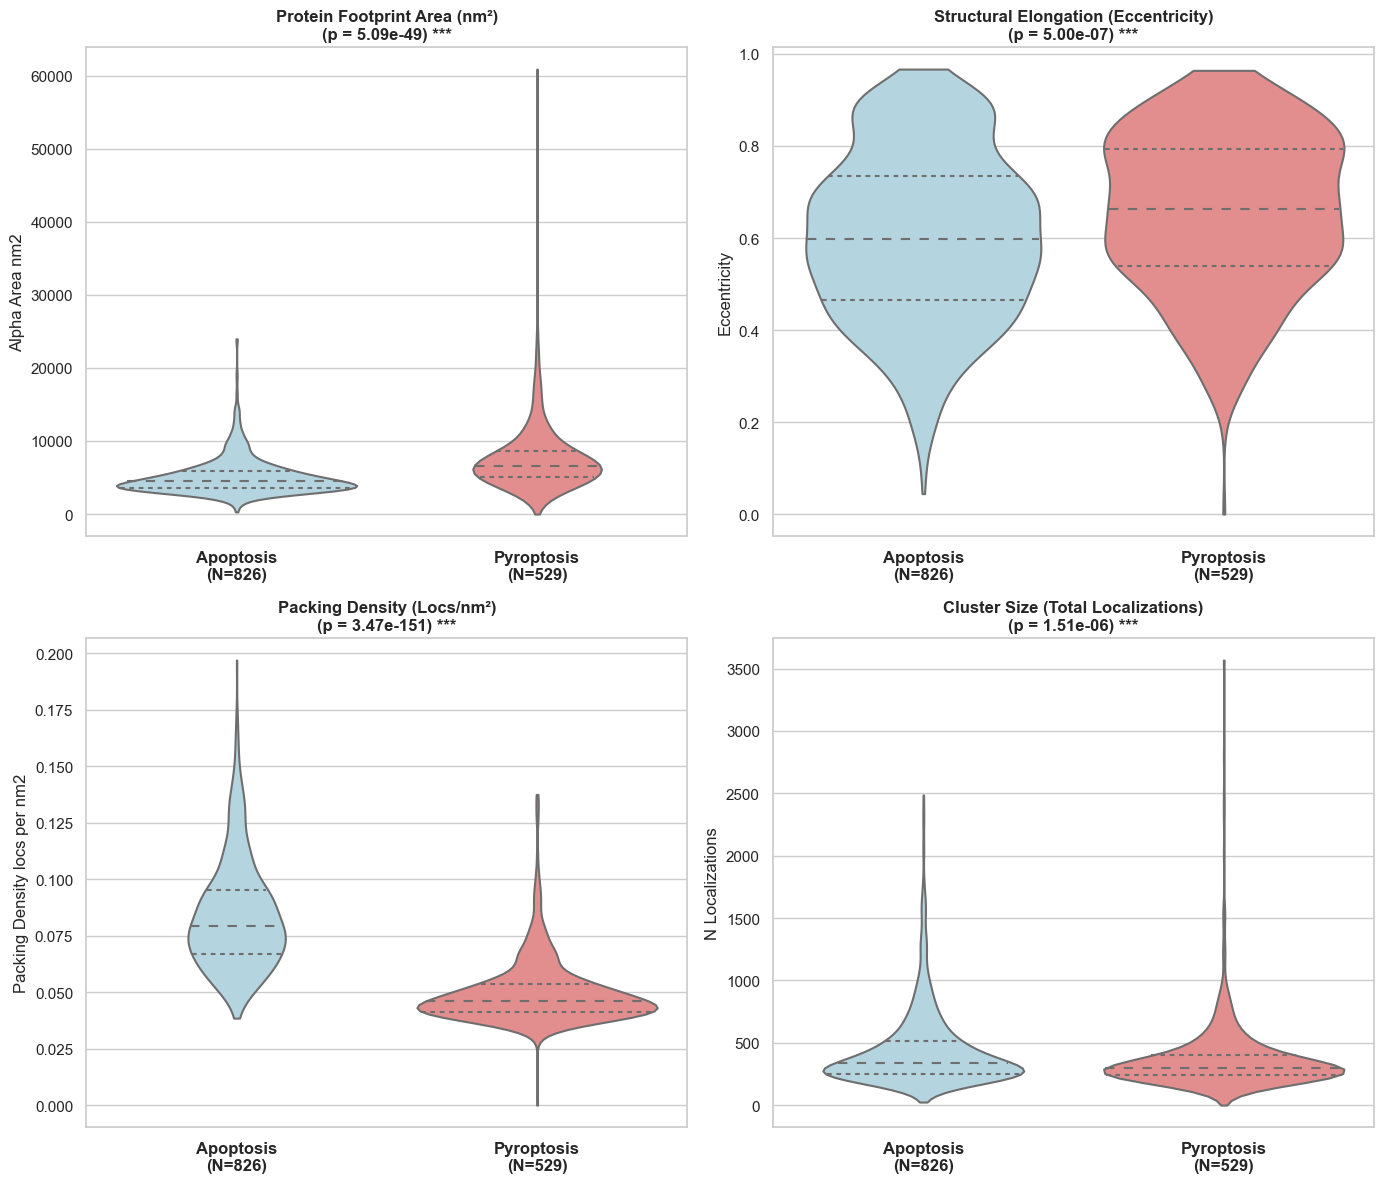

In [101]:
%matplotlib inline

import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
from scipy.stats import mannwhitneyu
import tkinter as tk
from tkinter import filedialog
import os

# ==========================================
# 1. SETTINGS & CUSTOM GROUPS
# ==========================================
OUTPUT_DIR = r"Y:\Richard\FiguresAndDBSCAN\Wednesday\RBJ2\Analysis_Results"
os.makedirs(OUTPUT_DIR, exist_ok=True)

MAX_LOCALIZATIONS = 6000   
MAX_PACKING_DENSITY = 0.5  

# Ask the user for the names of the two groups being compared
print("--- Setup Comparison ---")
group1_name = input("Enter the name for Group 1 (e.g., 'Control'): ") or "Control"
group2_name = input("Enter the name for Group 2 (e.g., 'Apoptosis' or 'Pyroptosis'): ") or "Experimental"

# ==========================================
# 2. FILE SELECTION UI
# ==========================================
root = tk.Tk()
root.withdraw()
root.attributes('-topmost', True) 

print(f"\nWaiting for file selection...")
print(f"-> Step 1: Select all {group1_name} cell CSV files.")
group1_files = filedialog.askopenfilenames(title=f"Select {group1_name} CSVs", filetypes=[("CSV Files", "*.csv")])

print(f"-> Step 2: Select all {group2_name} cell CSV files.")
group2_files = filedialog.askopenfilenames(title=f"Select {group2_name} CSVs", filetypes=[("CSV Files", "*.csv")])

root.destroy()

if not group1_files or not group2_files:
    raise ValueError("Missing files. You must select at least one file for both groups.")

# ==========================================
# 3. DATA MERGING & QUALITY CONTROL
# ==========================================
df_list = []

for file in group1_files:
    temp_df = pd.read_csv(file)
    temp_df['Condition'] = group1_name
    df_list.append(temp_df)

for file in group2_files:
    temp_df = pd.read_csv(file)
    temp_df['Condition'] = group2_name
    df_list.append(temp_df)

master_df = pd.concat(df_list, ignore_index=True)
initial_count = len(master_df)

# Apply Fiducial / Outlier Filters
master_df = master_df[
    (master_df['N_Localizations'] <= MAX_LOCALIZATIONS) & 
    (master_df['Packing_Density_locs_per_nm2'] <= MAX_PACKING_DENSITY)
]

# Calculate final N values for the labels
counts = master_df['Condition'].value_counts()
n1 = counts.get(group1_name, 0)
n2 = counts.get(group2_name, 0)

print(f"\nSuccessfully loaded valid clusters:")
print(f" - {group1_name}: {n1} clusters")
print(f" - {group2_name}: {n2} clusters")

# ==========================================
# 4. STATISTICAL TESTING & VISUALIZATION
# ==========================================
metrics = [
    "Alpha_Area_nm2", 
    "Eccentricity", 
    "Packing_Density_locs_per_nm2", 
    "N_Localizations"
]

titles = [
    "Protein Footprint Area (nm²)", 
    "Structural Elongation (Eccentricity)", 
    "Packing Density (Locs/nm²)", 
    "Cluster Size (Total Localizations)"
]

sns.set_theme(style="whitegrid")
fig, axes = plt.subplots(2, 2, figsize=(14, 12))
axes = axes.flatten()

palette = {group1_name: "lightblue", group2_name: "lightcoral"}

print("\n--- STATISTICAL RESULTS (Mann-Whitney U Test) ---")

for i, metric in enumerate(metrics):
    data1 = master_df[master_df['Condition'] == group1_name][metric].dropna()
    data2 = master_df[master_df['Condition'] == group2_name][metric].dropna()
    
    stat, p_value = mannwhitneyu(data1, data2, alternative='two-sided')
    
    if p_value < 0.001: sig = "***"
    elif p_value < 0.01: sig = "**"
    elif p_value < 0.05: sig = "*"
    else: sig = "ns"
        
    print(f"{metric}: p-value = {p_value:.4e} [{sig}]")
    
    ax = axes[i]
    sns.violinplot(
        data=master_df, x="Condition", y=metric, 
        ax=ax, palette=palette, inner="quartile",
        cut=0
    )
    
    # Add Title with Stats
    ax.set_title(f"{titles[i]}\n(p = {p_value:.2e}) {sig}", fontweight='bold')
    ax.set_xlabel("")
    ax.set_ylabel(metric.replace("_", " "))
    
    # --- THE FIX: ADD 'N' TO THE X-AXIS LABELS ---
    # Automatically appends \n(N=150) to the bottom of the violin plot categories
    new_labels = [f"{group1_name}\n(N={n1})", f"{group2_name}\n(N={n2})"]
    ax.set_xticks([0, 1])
    ax.set_xticklabels(new_labels, fontsize=12, fontweight='bold')

plt.tight_layout()

# Save the figure dynamically based on your group names
save_path = os.path.join(OUTPUT_DIR, f"Stats_{group1_name}_vs_{group2_name}.png")
plt.savefig(save_path, dpi=300, bbox_inches='tight')
print(f"\nFigure successfully saved to: {save_path}")

plt.show()

In [59]:
import h5py
import numpy as np
import pandas as pd

# ==========================================
# 1. SETTINGS
# ==========================================
FILE_PATH = r"Y:\Richard\FiguresAndDBSCAN\Wednesday\RBJ2\B3 10,10,200dbscan.hdf5"

# The minimum number of localizations to flag for review. 
# Since your norm is ~250, setting this to 1000 will catch all the extreme outliers.
MIN_LOCALIZATIONS = 1000 

# ==========================================
# 2. LOAD & AGGREGATE DATA
# ==========================================
print(f"Scanning HDF5 for massive clusters (>= {MIN_LOCALIZATIONS} locs)...")

with h5py.File(FILE_PATH, 'r') as f:
    locs = f['locs'][:]

# Filter out background noise (group -1)
locs = locs[locs['group'] >= 0]

# Load into a Pandas DataFrame for lightning-fast aggregation
df = pd.DataFrame({
    'group': locs['group'],
    'frame': locs['frame']
})

# Calculate stats for every single group
print("Calculating localization counts and frame spans...")
summary = df.groupby('group').agg(
    N_Localizations=('group', 'count'),
    Active_Frames=('frame', 'nunique'),
    Frame_Span=('frame', lambda x: x.max() - x.min())
).reset_index()

# ==========================================
# 3. FILTER & DISPLAY ANOMALIES
# ==========================================
# Isolate the massive clusters and sort them from biggest to smallest
anomalies = summary[summary['N_Localizations'] >= MIN_LOCALIZATIONS].sort_values('N_Localizations', ascending=False)

if anomalies.empty:
    print(f"\nNo clusters found with {MIN_LOCALIZATIONS} or more localizations.")
else:
    print(f"\nFound {len(anomalies)} extreme clusters:\n")
    print("-" * 65)
    print(f"{'Group_ID':<12} | {'N_Localizations':<15} | {'Active_Frames':<15} | {'Frame_Span':<15}")
    print("-" * 65)
    
    for index, row in anomalies.iterrows():
        print(f"{int(row['group']):<12} | {int(row['N_Localizations']):<15} | {int(row['Active_Frames']):<15} | {int(row['Frame_Span']):<15}")
    print("-" * 65)

Scanning HDF5 for massive clusters (>= 1000 locs)...
Calculating localization counts and frame spans...

Found 84 extreme clusters. Here is the breakdown:

-----------------------------------------------------------------
Group_ID     | N_Localizations | Active_Frames   | Frame_Span     
-----------------------------------------------------------------
219          | 4298            | 4298            | 39986          
58           | 4016            | 4016            | 39988          
314          | 3539            | 3539            | 39961          
581          | 3153            | 3153            | 39971          
372          | 2885            | 2885            | 39970          
36           | 2487            | 2487            | 39993          
37           | 2418            | 2418            | 39997          
369          | 2329            | 2329            | 39963          
8            | 2272            | 2272            | 39960          
177          | 2087            | 2087     

--- SMLM Particle Averager ---


Enter the condition you are averaging (e.g., 'Control', 'Apoptosis', 'Pyroptosis'):  Pyroptosis


-> Select ONE representative HDF5 file for Pyroptosis...
Loading data from G3 pos1 10,10,200dbscan.hdf5...
Found 968 total clusters. Filtering and aligning...
Successfully aligned and stacked 967 clusters!
Image saved to: Y:\Richard\FiguresAndDBSCAN\Wednesday\RBJ2\Analysis_Results\Average_Oligomer_Pyroptosis.png


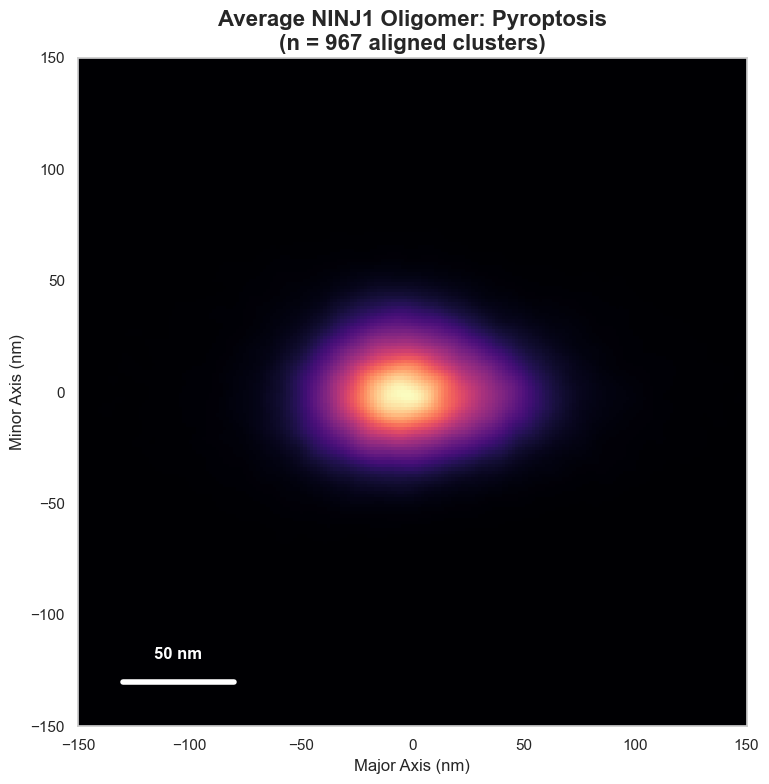

In [107]:
# --- PUT THIS AT THE VERY TOP OF YOUR CELL ---
%matplotlib inline 
# ---------------------------------------------

import h5py
import numpy as np
import matplotlib.pyplot as plt
from scipy.ndimage import gaussian_filter
import tkinter as tk
from tkinter import filedialog
import os

# ==========================================
# 1. SETTINGS & SETUP
# ==========================================
CAMERA_PIXEL_SIZE = 130.0 
OUTPUT_DIR = r"Y:\Richard\FiguresAndDBSCAN\Wednesday\RBJ2\Analysis_Results"
os.makedirs(OUTPUT_DIR, exist_ok=True)

# Filters (to ensure we only average real biology)
MIN_LOCALIZATIONS = 50
MAX_LOCALIZATIONS = 6000
MAX_PACKING_DENSITY = 0.5

print("--- SMLM Particle Averager ---")
condition_name = input("Enter the condition you are averaging (e.g., 'Control', 'Apoptosis', 'Pyroptosis'): ") or "Average_Oligomer"

# ==========================================
# 2. LOAD HDF5 DATA
# ==========================================
root = tk.Tk()
root.withdraw()
root.attributes('-topmost', True) 

print(f"-> Select ONE representative HDF5 file for {condition_name}...")
file_path = filedialog.askopenfilename(title=f"Select {condition_name} HDF5", filetypes=[("HDF5 Files", "*.hdf5")])
root.destroy()

if not file_path:
    raise ValueError("No file selected. Execution stopped.")

print(f"Loading data from {os.path.basename(file_path)}...")

with h5py.File(file_path, 'r') as f:
    locs = f['locs'][:]

# Filter background
locs = locs[locs['group'] >= 0]
x_nm = locs['x'] * CAMERA_PIXEL_SIZE
y_nm = locs['y'] * CAMERA_PIXEL_SIZE
groups = locs['group']

unique_clusters = np.unique(groups)
print(f"Found {len(unique_clusters)} total clusters. Filtering and aligning...")

# ==========================================
# 3. THE ALIGNMENT ENGINE (PCA & SKEWNESS)
# ==========================================
master_x = []
master_y = []
valid_clusters = 0

for cluster_id in unique_clusters:
    idx = (groups == cluster_id)
    x = x_nm[idx]
    y = y_nm[idx]
    
    N_locs = len(x)
    if N_locs < MIN_LOCALIZATIONS or N_locs > MAX_LOCALIZATIONS:
        continue
        
    pts = np.vstack((x, y)).T
    
    # Simple area estimate to filter ultra-dense beads
    x_range = np.max(x) - np.min(x)
    y_range = np.max(y) - np.min(y)
    approx_area = (x_range * y_range) * 0.785 # Ellipse area
    density = N_locs / approx_area if approx_area > 0 else 100
    
    if density > MAX_PACKING_DENSITY:
        continue
        
    valid_clusters += 1
    
    # Step 1: Center the cluster
    pts = pts - np.mean(pts, axis=0)
    
    # Step 2: PCA Rotation (Align Major Axis to X-Axis)
    cov = np.cov(pts.T)
    evals, evecs = np.linalg.eigh(cov)
    
    # Get the angle of the major eigenvector
    major_vector = evecs[:, np.argmax(evals)]
    angle = np.arctan2(major_vector[1], major_vector[0])
    
    # Rotate points by -angle
    c, s = np.cos(-angle), np.sin(-angle)
    x_rot = pts[:, 0] * c - pts[:, 1] * s
    y_rot = pts[:, 0] * s + pts[:, 1] * c
    
    # Step 3: Skewness Alignment 
    # (Forces the "open" side of C-shaped arcs to face the same way)
    if np.mean(x_rot**3) < 0:
        x_rot = -x_rot
    if np.mean(y_rot**3) < 0:
        y_rot = -y_rot
        
    master_x.extend(x_rot)
    master_y.extend(y_rot)

print(f"Successfully aligned and stacked {valid_clusters} clusters!")

# ==========================================
# 4. GENERATE HIGH-RES DENSITY MAP
# ==========================================
if len(master_x) == 0:
    raise ValueError("No valid clusters remained after filtering.")

# Create a 2D Histogram (300x300 nm view)
window_size = 150 # nm from center
bins = np.linspace(-window_size, window_size, 200)

H, xedges, yedges = np.histogram2d(master_x, master_y, bins=bins)

# Apply a Gaussian blur to simulate physical protein volume
H = gaussian_filter(H, sigma=2.0)

# Plotting
fig, ax = plt.subplots(figsize=(8, 8))
fig.canvas.manager.set_window_title(f"Average Oligomer - {condition_name}")

# Use the 'magma' or 'inferno' colormap for that classic microscopy heatmap look
im = ax.imshow(H.T, origin='lower', extent=[-window_size, window_size, -window_size, window_size], cmap='magma')

# Formatting
ax.set_title(f"Average NINJ1 Oligomer: {condition_name}\n(n = {valid_clusters} aligned clusters)", fontsize=16, fontweight='bold')
ax.set_xlabel("Major Axis (nm)", fontsize=12)
ax.set_ylabel("Minor Axis (nm)", fontsize=12)
ax.grid(False)

# Add a clean 50nm Scale Bar
ax.plot([-130, -80], [-130, -130], color='white', linewidth=4)
ax.text(-105, -120, "50 nm", color='white', ha='center', fontsize=12, fontweight='bold')

plt.tight_layout()

# Save the High-Res Image
save_path = os.path.join(OUTPUT_DIR, f"Average_Oligomer_{condition_name}.png")
plt.savefig(save_path, dpi=300, bbox_inches='tight')
print(f"Image saved to: {save_path}")

plt.show()

-> Select CSVs for: Control


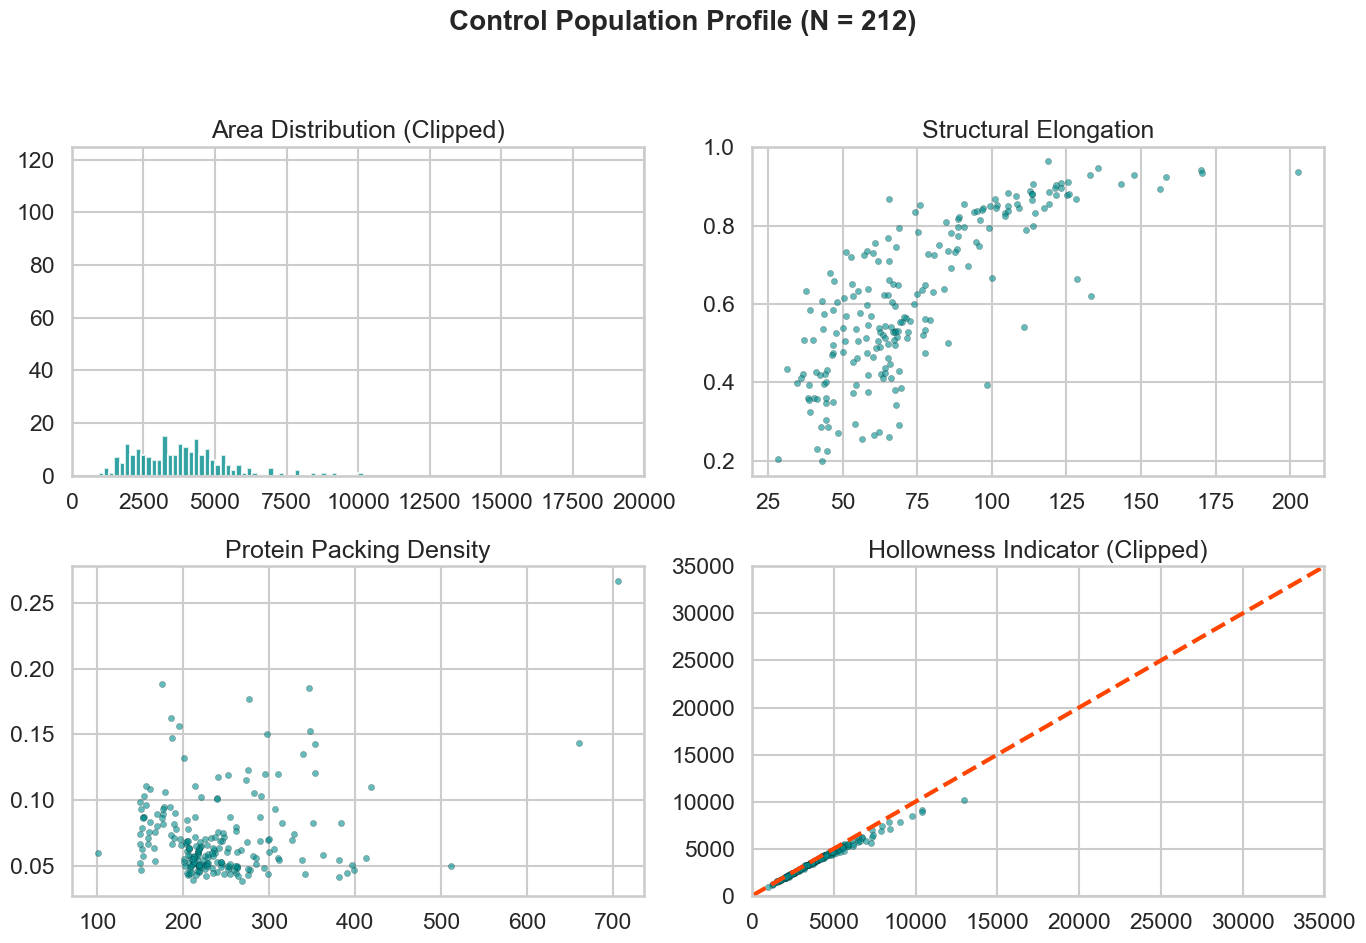

-> Select CSVs for: Apoptosis


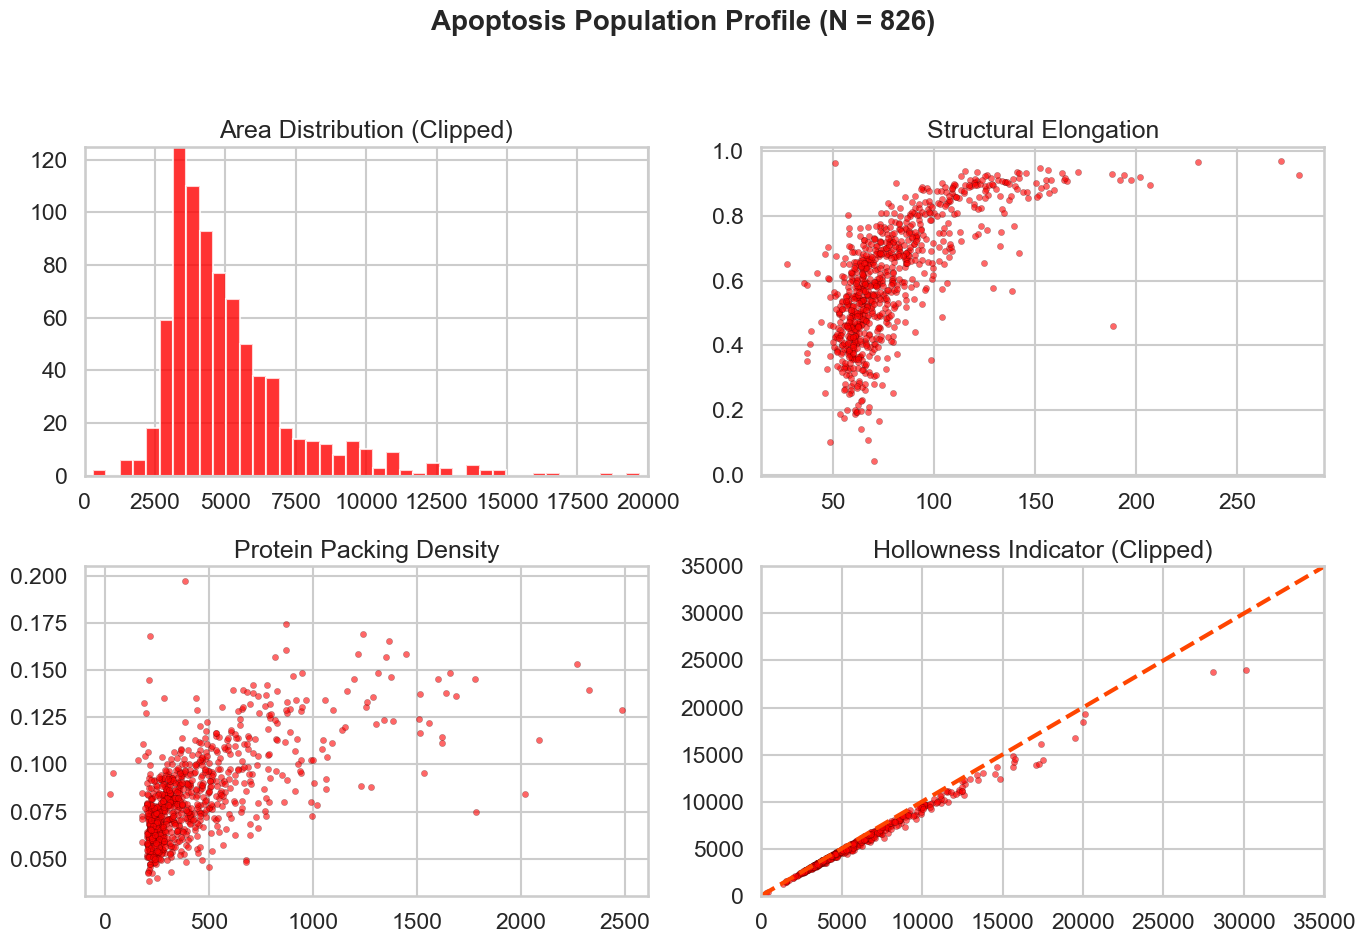

-> Select CSVs for: Pyroptosis


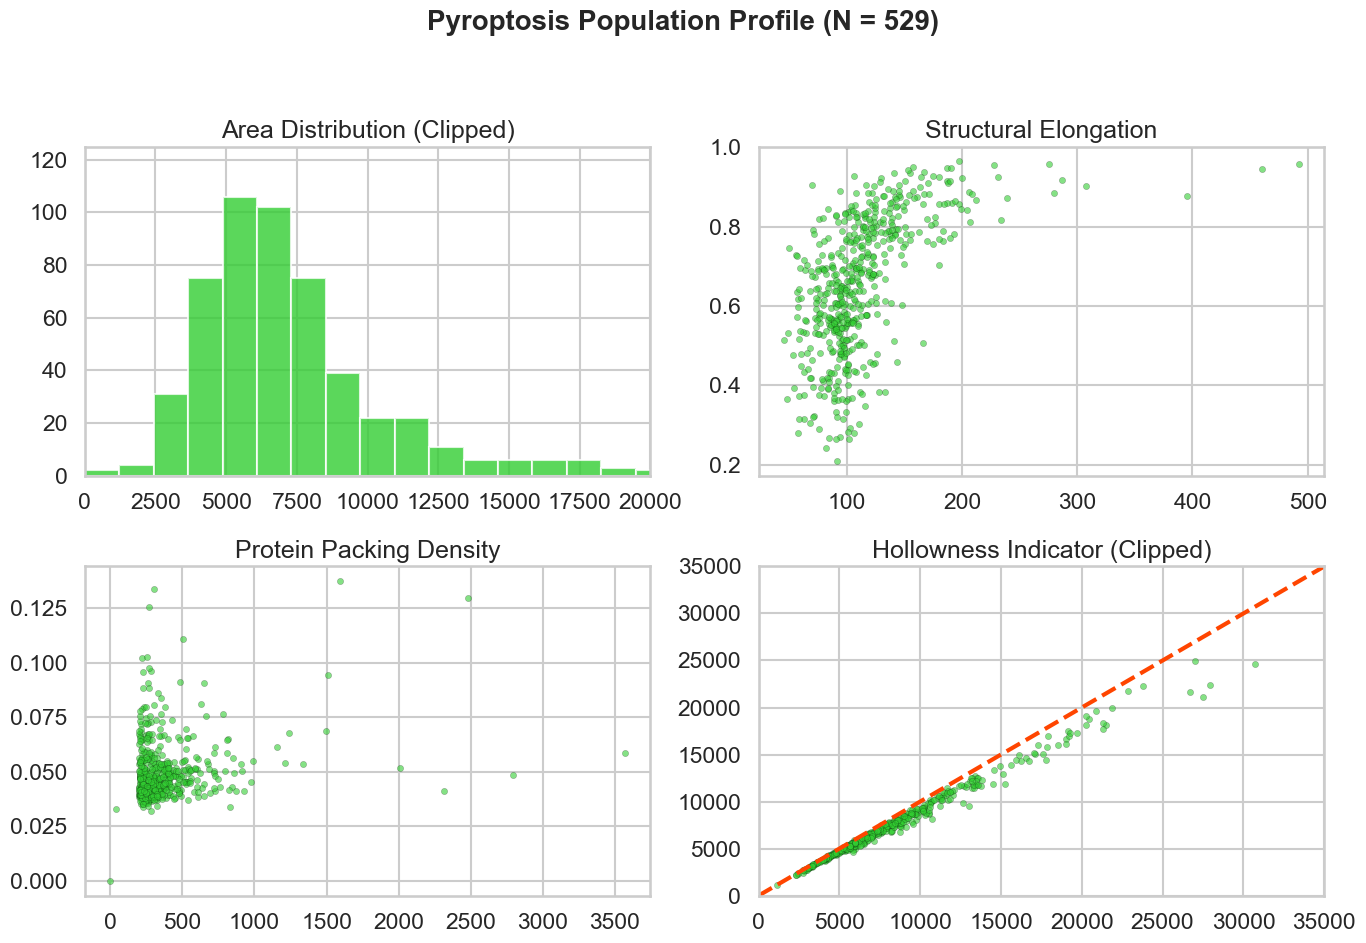

Done! All cumulative dashboards saved.


In [121]:
%matplotlib inline

import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import tkinter as tk
from tkinter import filedialog
import os

# ==========================================
# 1. SETTINGS
# ==========================================
OUTPUT_DIR = r"Y:\Richard\FiguresAndDBSCAN\Wednesday\RBJ2\Analysis_Results"
os.makedirs(OUTPUT_DIR, exist_ok=True)
CONDITIONS = ["Control", "Apoptosis", "Pyroptosis"]

# Hide background window
root = tk.Tk()
root.withdraw()
root.attributes('-topmost', True) 

# ==========================================
# 2. PLOTTING LOOP
# ==========================================
COLOR_MAP = {"Control": "#008B8B", "Apoptosis": "#FF0000", "Pyroptosis": "#32CD32"}

for condition in CONDITIONS:
    print(f"-> Select CSVs for: {condition}")
    file_paths = filedialog.askopenfilenames(title=f"Select all {condition} CSVs", filetypes=[("CSV Files", "*.csv")])
    if not file_paths: continue
    
    df = pd.concat([pd.read_csv(f) for f in file_paths], ignore_index=True)
    current_color = COLOR_MAP.get(condition, "royalblue")
    
    fig, axes = plt.subplots(2, 2, figsize=(14, 10))
    fig.suptitle(f"{condition} Population Profile (N = {len(df)})", fontsize=20, fontweight='bold')

    # A: Areas (HARD-CODED LIMITS)
    axes[0, 0].hist(df["Alpha_Area_nm2"], bins=50, alpha=0.8, color=current_color)
    axes[0, 0].set_xlim(0, 20000) 
    axes[0, 0].set_ylim(0, 125)   
    axes[0, 0].set_title("Area Distribution (Clipped)")
    
    # B: Shapes (Perfect as is - dynamic)
    axes[0, 1].scatter(df["Major_Axis_nm"], df["Eccentricity"], alpha=0.6, s=20, color=current_color, edgecolors='black', linewidth=0.2)
    axes[0, 1].set_title("Structural Elongation")
    
    # C: Packing Density (Perfect as is - dynamic)
    axes[1, 0].scatter(df["N_Localizations"], df["Packing_Density_locs_per_nm2"], alpha=0.6, s=20, color=current_color, edgecolors='black', linewidth=0.2)
    axes[1, 0].set_title("Protein Packing Density")
    
    # D: Hollowness (X limit HARD-CODED)
    axes[1, 1].scatter(df["Convex_Area_nm2"], df["Alpha_Area_nm2"], alpha=0.6, s=20, color=current_color, edgecolors='black', linewidth=0.2)
    axes[1, 1].plot([0, 35000], [0, 35000], '#FF4500', lw=3, linestyle='--')
    axes[1, 1].set_xlim(0, 35000)
    axes[1, 1].set_ylim(0, 35000)
    axes[1, 1].set_title("Hollowness Indicator (Clipped)")

    plt.tight_layout(rect=[0, 0.03, 1, 0.95])
    plt.savefig(os.path.join(OUTPUT_DIR, f"Cumulative_{condition}_FINAL.png"), dpi=300)
    plt.show()

root.destroy()
print("Done! All cumulative dashboards saved.")